# Evaluating Saved Model
This notebook loads the trained model and validation data to evaluate testing performance.

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
# !git clone https://github.com/Phantom-fs/Soil-Classification-Dataset

In [13]:
dataset_dir = "Soil-Classification-Dataset/CyAUG-Dataset"
IMG_SIZE = 224
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)
class_names = val_ds.class_names
print(class_names)

Found 5096 files belonging to 7 classes.
Using 1019 files for validation.
['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


In [14]:
AUTOTUNE = tf.data.AUTOTUNE
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [15]:
model = tf.keras.models.load_model(
    "saved_model/soil_classification_model_V_1.0.0.1.0.keras",
    custom_objects={
        "preprocess_input": tf.keras.applications.efficientnet_v2.preprocess_input
    }
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,636,167 (71.09 MB)

 Trainable params: 6,190,999 (23.62 MB)

 Non-trainable params: 63,168 (246.75 KB)

 Optimizer params: 12,382,000 (47.23 MB)

# Performance Evaluation
Evaluate the model using the validation dataset and visualize training history.

In [16]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 313ms/step - accuracy: 0.9490 - loss: 0.1879
Validation Loss: 0.1879
Validation Accuracy: 0.9490


In [17]:
import numpy as np
from sklearn.metrics import classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report: \n", classification_report(y_true, y_pred, target_names=class_names))

Classification Report: 
                precision    recall  f1-score   support

Alluvial_Soil       0.89      0.92      0.90       128
    Arid_Soil       0.77      0.83      0.80        52
   Black_Soil       0.97      0.99      0.98       227
Laterite_Soil       0.80      0.77      0.79        43
Mountain_Soil       0.91      0.84      0.87        49
     Red_Soil       0.99      0.98      0.98       221
  Yellow_Soil       0.99      0.98      0.98       299

     accuracy                           0.95      1019
    macro avg       0.90      0.90      0.90      1019
 weighted avg       0.95      0.95      0.95      1019



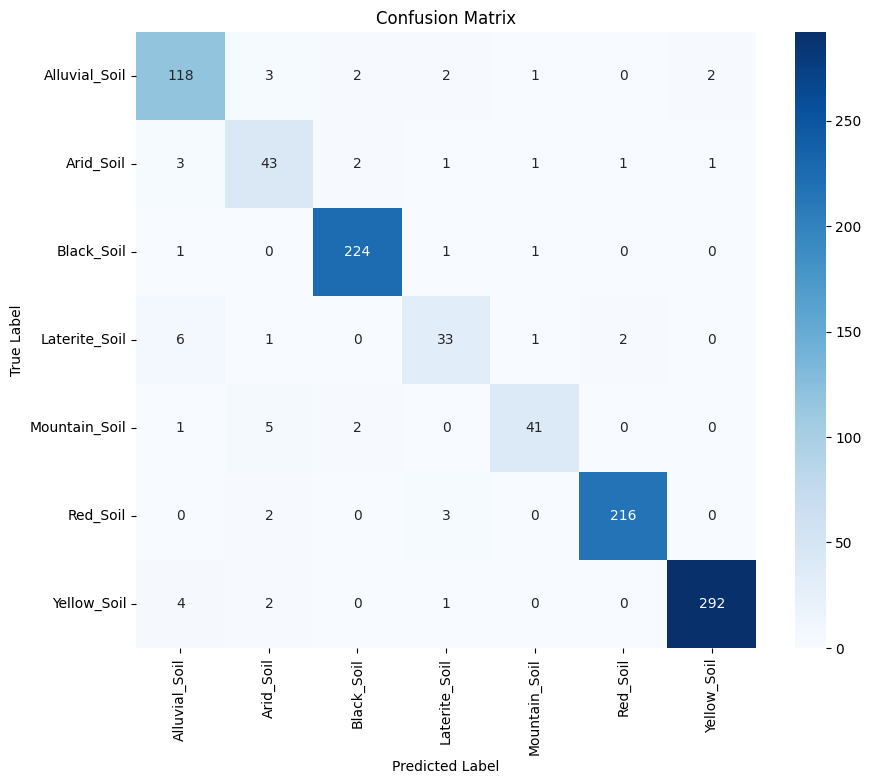

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report Summary

Based on the classification report generated above, the following observations can be made on the model's performance on the validation set:

- **Overall Accuracy**: The model correctly predicts the soil type with **95% accuracy** across the 1019 validation images, indicating a highly effective model.
- **Top Performing Classes**: The model has exceptional precision and recall for **Red Soil, Yellow Soil, and Black Soil** (all with an F1-score of 0.98).
- **Good Performers**: **Alluvial Soil** (F1-score 0.90) and **Mountain Soil** (F1-score 0.87) also showed strong results with well-balanced precision and recall.
- **Areas for Improvement**: The performance on **Laterite Soil** (F1-score 0.79) and **Arid Soil** (F1-score 0.80) is comparatively lower. These soil types might share visual similarities with other classes or have slightly lower representation in the training variations, contributing to slightly higher misclassifications.
- **Balance**: The proximity of the macro average (0.90) and weighted average (0.95) indicates that the model is well-balanced across the different classes despite some class imbalances in the support counts (e.g., 299 images for Yellow Soil vs. 43 for Laterite Soil).